2025-10-21 创建
1. 解决风-潮-流-浪场的预报功能
2. 预留损失函数接口，为PINN做准备
3. 使用U-Net CNN神经网络

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader, TensorDataset
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
# 自建函数库
from main_python_MyFunctions import c_PickleHandler

d:\anaconda3\envs\cnn-model\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda3\envs\cnn-model\lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.5, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 加载数据pkl文件
文件路径../datas/*.pkl

二维为*_2d.pkl；一维为*_piled.pkl

In [2]:
def f_load_pickle(file_path):
    handle = c_PickleHandler(file_path)
    data = handle.load_data()
    return data

if __name__=="__main__":    
    # 读取文件
    print('**loading files ...')

    # env_type = input("Please input the environment type (wave, surge, current): ")
    env_type = 'wave'
    
    # 读取mat文件
    wind_2d = f_load_pickle('../datas/wind_2d.pkl')
    if env_type == 'surge':
        surge_2d = f_load_pickle('../datas/surge_2d.pkl')
    elif env_type == 'current':
        surge_2d = f_load_pickle('../datas/surge_2d.pkl')
        current_2d = f_load_pickle('../datas/current_2d.pkl')
    elif env_type == 'wave':
        output_map_2d = f_load_pickle('../datas/wave_2d.pkl')

    # 查询surge_piled绝对值大于3的值的索引
    # 只保留绝对值小于3的风暴潮数据
    if env_type == 'surge':
        print('**cleaning surge data ...')
        surge_2d[np.abs(surge_2d) > 5] = 0
        output_map_2d = surge_2d
    elif env_type == 'current':
        print('**cleaning current data ...')
        current_2d[np.abs(surge_2d) > 5] = 0  # 注意：这里可能是打字错误，应为 current_2d

    # 正确提取 wind_2d 的 real 和 imag（关键修复：用 fields 访问）
    wind_real = wind_2d['real'].astype(np.float64)  # (110387, 56, 54), 纯 float64
    wind_imag = wind_2d['imag'].astype(np.float64)  # 同上
    wind_combined = np.stack([wind_real, wind_imag], axis=1)  # (110387, 2, 56, 54), 纯 float64

    # current 处理（如果适用）
    if env_type == 'current':
        current_real = current_2d['real'].astype(np.float64)
        current_imag = current_2d['imag'].astype(np.float64)
        output_map_2d = np.stack([current_real, current_imag], axis=1)

    # 网格数据
    x = np.arange(105.3, 116.01, 0.2, dtype = float)
    y = np.arange(12, 23.01, 0.2, dtype = float)
    X,Y = np.meshgrid(x, y)

    print("Data loading fixed: wind_combined dtype =", wind_combined.dtype)  # 应为 float64
    print("Data loading fixed: wind_combined shape =", wind_combined.shape)
    if env_type == 'surge':
        print("data type (surge): ",output_map_2d.dtype)
    elif env_type == 'current':
        print("data type (current): ",output_map_2d.dtype)
    elif env_type == 'wave':
        print("data type (wave): ",output_map_2d.dtype)

**loading files ...
Data loading fixed: wind_combined dtype = float64
Data loading fixed: wind_combined shape = (110387, 2, 56, 54)
data type (wave):  float64


In [3]:
# 检查原始数据中的 NaN/Inf
print("Wind data stats:")
print(f"NaN in wind_real: {np.any(np.isnan(wind_real))}")
print(f"Inf in wind_real: {np.any(np.isinf(wind_real))}")
print(f"NaN in wind_imag: {np.any(np.isnan(wind_imag))}")
print(f"Inf in wind_imag: {np.any(np.isinf(wind_imag))}")

print("\nOutput data stats:")
print(f"NaN in output_map_2d: {np.any(np.isnan(output_map_2d))}")
print(f"Inf in output_map_2d: {np.any(np.isinf(output_map_2d))}")

# 示例：打印有 NaN 的样本索引（如果有）
nan_wind_idx = np.where(np.isnan(wind_combined).any(axis=(1,2,3)))
nan_output_idx = np.where(np.isnan(output_map_2d).any(axis=(1,2)))
print(f"Wind NaN samples: {len(nan_wind_idx[0])}")
print(f"Output NaN samples: {len(nan_output_idx[0])}")

# 如果有 NaN，查看范围
print(f"Wind min/max: {np.nanmin(wind_combined):.2f} / {np.nanmax(wind_combined):.2f}")
print(f"Output min/max: {np.nanmin(output_map_2d):.2f} / {np.nanmax(output_map_2d):.2f}")

Wind data stats:
NaN in wind_real: True
Inf in wind_real: False
NaN in wind_imag: True
Inf in wind_imag: False

Output data stats:
NaN in output_map_2d: True
Inf in output_map_2d: False
Wind NaN samples: 110387
Output NaN samples: 110387
Wind min/max: -66.59 / 65.15
Output min/max: 0.00 / 27.08


In [4]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 清理 NaN/Inf：替换为 0（或均值），或删除样本
# 选项1: 替换（简单，保留所有样本）
# wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
# output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0, posinf=np.finfo(np.float64).max * 0.999, neginf=np.finfo(np.float64).min * 0.999)
wind_combined_clean = np.nan_to_num(wind_combined, nan=0.0)
output_map_2d_clean = np.nan_to_num(output_map_2d, nan=0.0)

# 选项2: 删除有 NaN 的样本（如果 NaN 少，推荐；否则用选项1）
# valid_idx_wind = ~np.isnan(wind_combined).any(axis=(1,2,3))
# valid_idx_output = ~np.isnan(output_map_2d).any(axis=(1,2))
# valid_idx = np.logical_and(valid_idx_wind, valid_idx_output)
# wind_combined_clean = wind_combined[valid_idx]
# output_map_2d_clean = output_map_2d[valid_idx]
# print(f"Removed {len(wind_combined) - len(wind_combined_clean)} invalid samples")

print("Cleaned data stats:")
print(f"NaN in cleaned wind: {np.any(np.isnan(wind_combined_clean))}")
print(f"NaN in cleaned output: {np.any(np.isnan(output_map_2d_clean))}")

# 现在归一化（sklearn 不会警告）
wind_flat = wind_combined_clean.reshape(len(wind_combined_clean), -1)
scaler_wind = StandardScaler()
wind_normalized = scaler_wind.fit_transform(wind_flat).reshape(wind_combined_clean.shape)

output_flat = output_map_2d_clean.reshape(len(output_map_2d_clean), -1)
scaler_output = StandardScaler()
output_normalized = scaler_output.fit_transform(output_flat).reshape(output_map_2d_clean.shape)

# 验证非 NaN
print(f"Normalized wind NaN: {np.any(np.isnan(wind_normalized))}")
print(f"Normalized output NaN: {np.any(np.isnan(output_normalized))}")
print(f"Wind normalized min/max: {np.nanmin(wind_normalized):.2f} / {np.nanmax(wind_normalized):.2f}")

Cleaned data stats:
NaN in cleaned wind: False
NaN in cleaned output: False
Normalized wind NaN: False
Normalized output NaN: False
Wind normalized min/max: -20.89 / 17.31


In [5]:
# 转换为 PyTorch tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
input_tensor = torch.from_numpy(wind_normalized).float().to(device)
output_tensor = torch.from_numpy(output_normalized).float().unsqueeze(1).to(device)

# 检查 tensor 非 NaN
print("Tensor NaN check:")
print(f"Input NaN: {torch.any(torch.isnan(input_tensor))}")
print(f"Output NaN: {torch.any(torch.isnan(output_tensor))}")

print("input_tensor shape:", input_tensor.shape)
print("output_tensor shape:", output_tensor.shape)

# Dataset/DataLoader（不变）
dataset = TensorDataset(input_tensor, output_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
print("Tensor conversion complete!")

Tensor NaN check:
Input NaN: False
Output NaN: False
input_tensor shape: torch.Size([110387, 2, 56, 54])
output_tensor shape: torch.Size([110387, 1, 56, 54])
Tensor conversion complete!


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    """双卷积块：不变"""
    def __init__(self, in_channels, out_channels, dropout_p=0.2):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(p=dropout_p)  # 2D Dropout，针对空间场
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    """修正 Down：先 DoubleConv (生成高分辨率 skip)，后 MaxPool (返回低分辨率)"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = DoubleConv(in_channels, out_channels)
        self.max_pool = nn.MaxPool2d(2)  # stride=2, padding=0

    def forward(self, x):
        skip = self.double_conv(x)  # 高分辨率，用于 skip
        pooled = self.max_pool(skip)  # 低分辨率，传给下一层
        return pooled, skip  # 返回两者

class Up(nn.Module):
    """修正 Up：ConvTranspose 上采样 + pad/crop 匹配 skip 尺寸 + cat + DoubleConv"""
    def __init__(self, in_channels, out_channels, dropout_p=0.1):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, out_channels, 2, stride=2)  # 2x 上采样
        self.conv = DoubleConv(out_channels * 2, out_channels)  # *2 for cat
        self.dropout = nn.Dropout2d(p=dropout_p)  # 加到 cat 后

    def forward(self, x1, x2):  # x1: 低分辨率上采样输入, x2: 高分辨率 skip
        x1 = self.up(x1)  # 上采样 (e.g., 3x3 → 6x6)
        
        # 精确匹配尺寸：如果 x1 > x2，用 crop；如果 x1 < x2，用 pad (处理 floor)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        
        if diffY > 0:  # x1 H < x2 H, pad
            x1 = nn.functional.pad(x1, (0, 0, diffY // 2, diffY - diffY // 2))  # pad H (bottom/top)
        elif diffY < 0:  # x1 H > x2 H, crop
            x1 = x1[:, :, :x2.size()[2], :]
            
        if diffX > 0:  # x1 W < x2 W, pad
            x1 = nn.functional.pad(x1, (diffX // 2, diffX - diffX // 2, 0, 0))  # pad W (right/left)
        elif diffX < 0:  # x1 W > x2 W, crop
            x1 = x1[:, :, :, :x2.size()[3]]
        
        x = torch.cat([x2, x1], dim=1)  # 通道拼接 (现在尺寸匹配)
        x = self.conv(x)
        return self.dropout(x)

class UNet(nn.Module):
    """修正 U-Net：确保输出精确 (1, 56, 54)"""
    def __init__(self, in_channels=2, out_channels=1, features=[32, 64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()

        # 下采样路径
        in_ch = in_channels
        for feature in features:
            self.downs.append(Down(in_ch, feature))
            in_ch = feature

        # 瓶颈：features[-1] * 2 以增加容量
        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        # 上采样路径：反转 features
        for feature in reversed(features):
            self.ups.append(Up(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)  # 1x1 conv 到输出通道
        self.final_norm = nn.BatchNorm2d(out_channels)  # 修正：使用 out_channels 而非 features[0]
    
    # 新增：权重初始化方法（He/Kaiming for ReLU）
    def init_weights(self, m):  # 注意签名：self, m
        if isinstance(m, nn.Conv2d):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.BatchNorm2d):  # 可选：BN 初始化
            nn.init.constant_(m.weight, 1)
            nn.init.constant_(m.bias, 0)
        # 可扩展：nn.Linear 等

    def forward(self, x):
        skip_connections = []

        # 下采样：收集高分辨率 skips
        for down in self.downs:
            x, skip = down(x)
            skip_connections.append(skip)

        # 瓶颈
        x = self.bottleneck(x)

        # 上采样：从深到浅匹配 skips (reversed)
        skip_connections = skip_connections[::-1]
        for up, skip in zip(self.ups, skip_connections):
            x = up(x, skip)

        x = self.final_conv(x)
        x = self.final_norm(x)  # 加 BN
        # 最终输出：sigmoid 假设 [0,1] 范围；根据波浪数据调整 (e.g., 无激活或 Tanh)
        return torch.sigmoid(x)

# 实例化模型（替换旧的）
if env_type in ['surge', 'wave']:
    model = UNet(in_channels=2, out_channels=1).to(device)
elif env_type == 'current':
    model = UNet(in_channels=2, out_channels=2).to(device)

# 应用权重初始化
model.apply(model.init_weights)

print(model)  # 检查结构

# 快速测试 forward 形状（添加这部分，运行前确保数据加载好）
def test_forward_shape(model, sample_data, device):
    model.eval()
    with torch.no_grad():
        sample_data = sample_data.to(device)
        output = model(sample_data)
        print(f"Input shape: {sample_data.shape}")
        print(f"Output shape: {output.shape}")  # 预期: [batch, 1, 56, 54]
        return output.shape

# 测试一个 batch（从 train_loader 取）
for data, _ in train_loader:
    test_forward_shape(model, data, device)
    break

UNet(
  (downs): ModuleList(
    (0): Down(
      (double_conv): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(2, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (5): ReLU(inplace=True)
          (6): Dropout2d(p=0.2, inplace=False)
        )
      )
      (max_pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Down(
      (double_conv): DoubleConv(
        (conv): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 

100%|██████████| 690/690 [00:44<00:00, 15.59it/s]


Epoch 1/100: Train Loss: 0.6377, Val Loss: 0.5490


100%|██████████| 690/690 [00:43<00:00, 15.88it/s]


Epoch 2/100: Train Loss: 0.5206, Val Loss: 0.4923


100%|██████████| 690/690 [00:43<00:00, 15.81it/s]


...

Epoch 53/100: Train Loss: 0.4085, Val Loss: 0.4174


100%|██████████| 690/690 [00:43<00:00, 15.95it/s]


Epoch 54/100: Train Loss: 0.4084, Val Loss: 0.4161


100%|██████████| 690/690 [00:43<00:00, 15.86it/s]


Early stopping triggered.


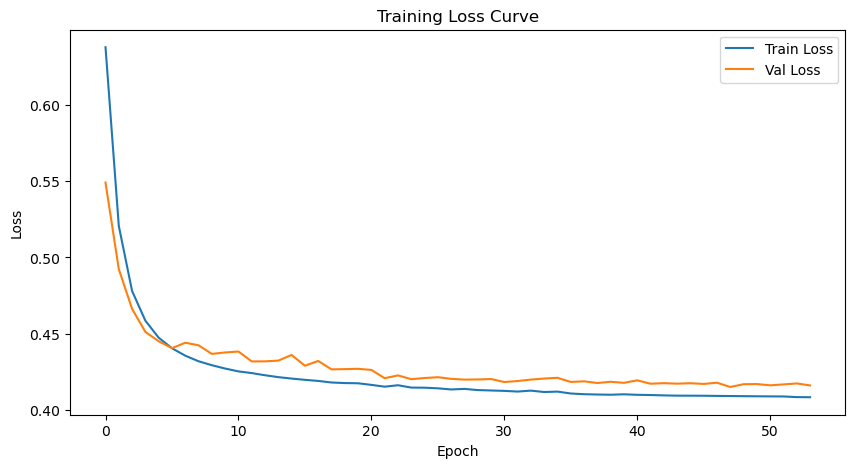

In [7]:
# model训练设置
import torch
import torch.nn as nn
import torch.nn.functional as F
from datetime import datetime

# 自定义损失函数：CombinedLoss (MSE + L1)
class CombinedLoss(nn.Module):
    def __init__(self, alpha=0.5):  # alpha: MSE 权重，1-alpha: L1 权重
        super(CombinedLoss, self).__init__()
        self.alpha = alpha
        self.mse = nn.MSELoss()
        self.l1 = nn.L1Loss()

    def forward(self, pred, target):
        mse_loss = self.mse(pred, target)
        l1_loss = self.l1(pred, target)
        return self.alpha * mse_loss + (1 - self.alpha) * l1_loss

# 自定义损失函数：HighValueDiceLoss
class HighValueDiceLoss(nn.Module):
    def __init__(self, threshold_factor=0.8, smooth=1e-6, reduction='mean'):
        """
        Dice Loss for high wave regions (> threshold_factor * per-sample max_wave).
        - threshold_factor: 0.8 表示每个样本的 0.8 * max_wave
        - smooth: 平滑项，避免除零
        - reduction: 'mean' (batch 平均) 或 'sum'
        """
        super(HighValueDiceLoss, self).__init__()
        self.threshold_factor = threshold_factor
        self.smooth = smooth
        self.reduction = reduction

    def forward(self, pred, target):
        # 处理 NaN/Inf（从你的数据清理继承）
        pred = torch.nan_to_num(pred, nan=0.0, posinf=1.0, neginf=0.0)
        target = torch.nan_to_num(target, nan=0.0, posinf=1.0, neginf=0.0)
        
        batch_size, _, H, W = target.shape
        
        # Per-sample max_wave: [batch] 形状
        per_sample_max = target.view(batch_size, -1).max(dim=1)[0]  # 每个样本的最大波高
        
        # 处理 max=0 的边缘情况（全低波，避免阈值=0）
        per_sample_max = torch.clamp(per_sample_max, min=1e-6)  # 最小阈值避免除零/全背景
        
        # Per-sample threshold: [batch] -> [batch, 1, 1, 1] 广播到 [batch,1,H,W]
        threshold = self.threshold_factor * per_sample_max.unsqueeze(1).unsqueeze(2).unsqueeze(3)
        
        # 阈值化：高波区为 1
        target_binary = (target > threshold).float()  # [batch,1,H,W]
        pred_sigmoid = torch.sigmoid(pred)  # 激活预测到 [0,1]
        pred_binary = (pred_sigmoid > threshold).float()  # 逐样本阈值化
        
        # 计算交集和并集（逐像素 sum，dim=(2,3) 忽略 H,W）
        intersection = (pred_binary * target_binary).sum(dim=(2, 3))  # [batch,1]
        pred_sum = pred_binary.sum(dim=(2, 3))
        target_sum = target_binary.sum(dim=(2, 3))
        
        # Dice 分数
        dice = (2. * intersection + self.smooth) / (pred_sum + target_sum + self.smooth)
        
        # 损失：1 - dice，batch 平均
        loss = 1 - dice.squeeze(1)  # 去掉通道维 [batch]
        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        else:
            return loss  # 无 reduction，返回 [batch]

# 自定义分位数损失函数
class QuantileLoss(nn.Module):
    def __init__(self, q=0.9):
        super(QuantileLoss, self).__init__()
        self.q = q

    def forward(self, pred, tgt):
        r = tgt - pred
        loss = torch.max(self.q * r, (self.q - 1) * r)
        return torch.mean(loss)

# 损失和优化器（不变）
# criterion = nn.MSELoss()
# criterion = CombinedLoss(alpha=0.6)  # 偏向 MSE 的比例
# criterion = HighValueDiceLoss(threshold_factor=0.6).to(device)
criterion = QuantileLoss(q=0.9).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)
model.apply(model.init_weights)  # 加到训练前

# 训练函数（移除 break 和形状打印）
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    num_batches = 0
    for batch_idx, (data, target) in enumerate(tqdm(loader)):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        # loss = 0.4*nn.L1Loss()(output, target) + 0.6*criterion(output, target)
        loss = F.mse_loss(output, target) + 0.2 * criterion(output, target)

        # NaN 监控
        if torch.isnan(loss):
            print(f"Warning: NaN loss at batch {batch_idx}! Check gradients/data.")
            break
        
        loss.backward()
        # 梯度裁剪（防爆炸）
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    return total_loss / num_batches if num_batches > 0 else float('inf')

# 验证函数（添加 NaN 检查）
def val_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    num_batches = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            # loss = criterion(output, target)
            loss = F.mse_loss(output, target) + 0.2 * criterion(output, target)
            if torch.isnan(loss):
                print("Warning: NaN val loss!")
                return float('inf')
            total_loss += loss.item()
            num_batches += 1
    return total_loss / num_batches if num_batches > 0 else float('inf')

# 训练循环
num_epochs = 100
train_losses, val_losses = [], []
best_val_loss = float('inf')
patience = 7
counter = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = val_epoch(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_model.pth')
    else:
        counter += 1
    if counter >= patience:
        print("Early stopping triggered.")
        break
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f'Epoch {epoch+1}/{num_epochs}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    if np.isnan(train_loss) or np.isnan(val_loss):
        print("Training failed: NaN detected. Stop.")
        break

# 绘制损失曲线
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Loss Curve')
plt.show()

# 保存模型，文件名后附加日期
torch.save(model.state_dict(), f'../datas/unet_{env_type}_model_{datetime.now().strftime("%Y%m%d_%H%M")}.pth')

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

# 加载模型权重
model.load_state_dict(torch.load(f'../datas/unet_{env_type}_model.pth', map_location=device))

# 步骤1: 从原始数据取一个样本（假设 wind_combined 和 output_map_2d 已加载且清理）
# 如果你有 scaler_wind 和 scaler_output（从归一化 cell），用它们；否则跳过标准化测试
sample_idx = 1314  # 取第sample_idx个样本；可改成其他索引
# wind_sample_complex = wind_combined_clean[sample_idx]  # (56, 54) complex? 等下，wind_combined 是 (N, 2, 56, 54) float
# 你的 wind_combined_clean 是分离后的 float (N, 2, H, W)，不是 complex。所以直接取 real/imag
wind_sample_real = wind_combined_clean[sample_idx, 0]  # (56, 54) real part
wind_sample_imag = wind_combined_clean[sample_idx, 1]  # (56, 54) imag part

# 步骤2: 标准化输入（匹配训练）
# 展平、transform、恢复形状
wind_sample_flat = np.stack([wind_sample_real, wind_sample_imag], axis=0).reshape(1, -1)  # (1, 2*56*54)
wind_sample_normalized = scaler_wind.transform(wind_sample_flat).reshape(1, 2, 56, 54)  # (1, 2, 56, 54)
wind_sample_tensor = torch.from_numpy(wind_sample_normalized).float().to(device)

# 步骤3: 模型推理
model.eval()
with torch.no_grad():
    env_pred_normalized = model(wind_sample_tensor)  # (1, 1, 56, 54)
    env_pred_normalized_np = env_pred_normalized.squeeze().cpu().numpy()  # (56, 54)

# 步骤4: 反归一化输出（恢复原始尺度）
env_pred_flat = env_pred_normalized_np.reshape(1, -1)  # (1, 56*54)
env_pred_np = scaler_output.inverse_transform(env_pred_flat).reshape(56, 54)  # (56, 54)

# 假设你已运行模型推理，并有：
# - wind_sample_real: (56, 54) 输入风场 real 部分
# - env_pred_np: (56, 54) 预测波浪场（反归一化后）
# - true_sample: (56, 54) 真实波浪场（从 output_map_2d[sample_idx]）
# - X, Y: meshgrid (56, 54)，Y 是 lat (行), X 是 lon (列)

# 如果没有 true_sample，从数据集中取
true_sample = output_map_2d_clean[sample_idx]  # (56, 54)



In [9]:
np.max(env_pred_np)

3.3450925

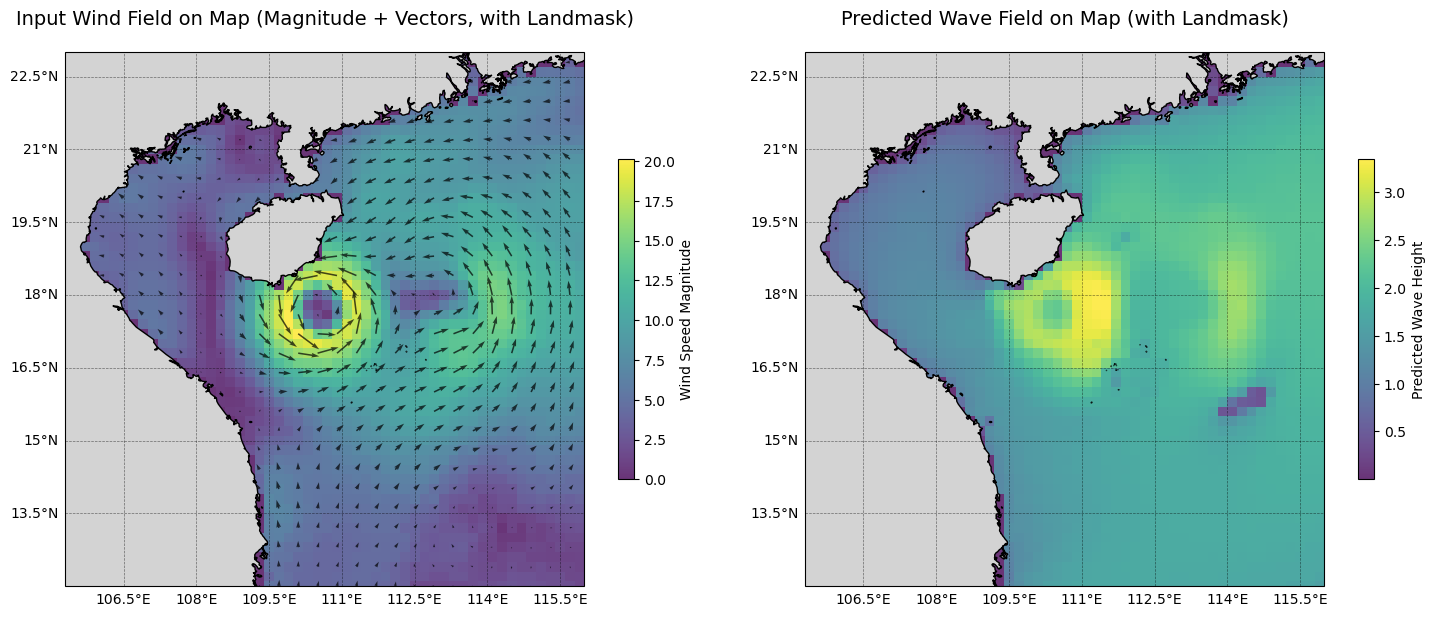

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Assuming X, Y, wind_sample_real, wind_sample_imag, env_pred_np are defined elsewhere
# wind_field_np = np.sqrt(wind_sample_real**2 + wind_sample_imag**2)  # 计算风速幅值 (move inside if needed)

# Define formatters if not already
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# Create subplots with shared projection
fig = plt.figure(figsize=(15, 6))
ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())

# Common extent
extent = [105.3, 116.0, 12.0, 23.0]

# Wind field subplot (ax1)
ax1.set_extent(extent, crs=ccrs.PlateCarree())

# Compute magnitude if not already
wind_field_np = np.sqrt(wind_sample_real**2 + wind_sample_imag**2)

# pcolormesh for magnitude
im1 = ax1.pcolormesh(X, Y, wind_field_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im1, ax=ax1, label='Wind Speed Magnitude', shrink=0.6)

# Quiver for wind vectors (subsample to avoid overcrowding, e.g., every 2nd point; adjust as needed)
skip = 2  # Adjust skip based on grid resolution
Xq = X[::skip, ::skip]
Yq = Y[::skip, ::skip]
Uq = wind_sample_real[::skip, ::skip]
Vq = wind_sample_imag[::skip, ::skip]
ax1.quiver(Xq, Yq, Uq, Vq, transform=ccrs.PlateCarree(), scale=400, width=0.003, color='black', alpha=0.7, zorder=2)  # Adjust scale as needed

# Add land and features
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--', zorder=5)
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER

ax1.set_title('Input Wind Field on Map (Magnitude + Vectors, with Landmask)', fontsize=14, pad=20)

# Predicted wave field subplot (ax2)
ax2.set_extent(extent, crs=ccrs.PlateCarree())

# pcolormesh for wave height
im2 = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
plt.colorbar(im2, ax=ax2, label='Predicted Wave Height', shrink=0.6)

# Add land and features
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)

# Gridlines
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER

ax2.set_title('Predicted Wave Field on Map (with Landmask)', fontsize=14, pad=20)

plt.tight_layout()
plt.show()

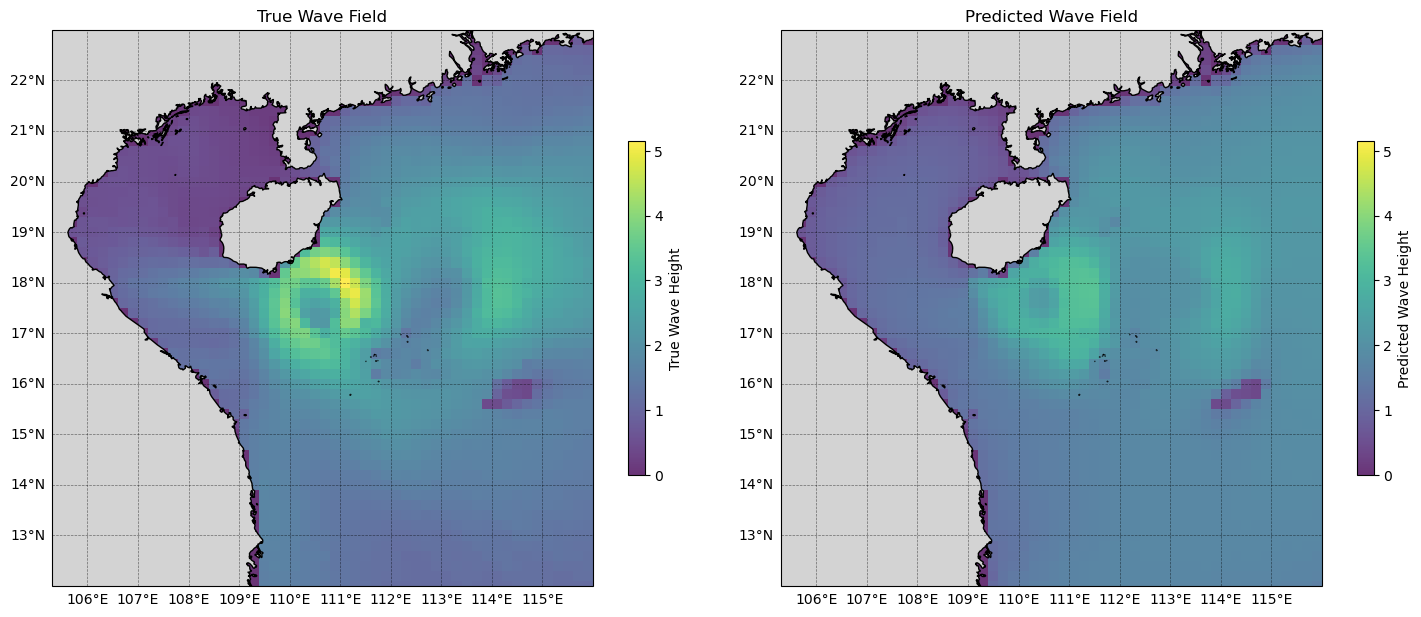

MSE: 0.0994, MAE: 0.2082
Correlation: 0.9530


In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# 假设 X, Y, true_sample, env_pred_np 已定义；如果未定义，请加载数据

# 定义格式器（如果之前代码中已定义，可忽略）
LONGITUDE_FORMATTER = LongitudeFormatter()
LATITUDE_FORMATTER = LatitudeFormatter()

# 对比图：预测 vs 真实（子图）
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=(15, 6))

# 真实场
ax1.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
im_true = ax1.pcolormesh(X, Y, true_sample, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
ax1.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
cbar1 = plt.colorbar(im_true, ax=ax1, label='True Wave Height', shrink=0.6)
# 可选：为真实场也设置 clim（默认已匹配数据范围）
# im_true.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())
gl1 = ax1.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl1.top_labels = False
gl1.right_labels = False
gl1.xlabels_top = False
gl1.ylabels_right = False
gl1.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl1.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
ax1.set_title('True Wave Field')

# 预测场
ax2.set_extent([105.3, 116.0, 12.0, 23.0], crs=ccrs.PlateCarree())
im_pred = ax2.pcolormesh(X, Y, env_pred_np, cmap='viridis', transform=ccrs.PlateCarree(), alpha=0.8, shading='auto', zorder=1)
ax2.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=2)
# 添加colorbar并设置范围，与真实场一致（在 im_pred 上调用 set_clim）
cbar2 = plt.colorbar(im_pred, ax=ax2, label='Predicted Wave Height', shrink=0.6)
im_pred.set_clim(vmin=im_true.get_array().min(), vmax=im_true.get_array().max())  # 修复：移到 im_pred 上
gl2 = ax2.gridlines(draw_labels=True, linewidth=0.5, color='black', alpha=0.5, linestyle='--')
gl2.top_labels = False
gl2.right_labels = False
gl2.xlabels_top = False
gl2.ylabels_right = False
gl2.xlocator = plt.FixedLocator(np.arange(105, 117, 1))
gl2.ylocator = plt.FixedLocator(np.arange(12, 24, 1))
gl2.xformatter = LONGITUDE_FORMATTER
gl2.yformatter = LATITUDE_FORMATTER
ax2.set_title('Predicted Wave Field')

plt.tight_layout()
plt.show()

# 打印对比统计
mse = np.mean((env_pred_np - true_sample)**2)
mae = np.mean(np.abs(env_pred_np - true_sample))
correlation = np.corrcoef(env_pred_np.flatten(), true_sample.flatten())[0, 1]
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}")
print(f"Correlation: {correlation:.4f}")